<a href="https://colab.research.google.com/github/oma-rivera/analisis_empresa_telcom/blob/main/Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
 plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  

En el dataset `users`, las columnas con valores faltantes son `city` y `churn_date`. La columna `city` tiene 469 valores nulos, equivalentes al 11.72% del total, por lo que conviene investigarla antes de imputar o eliminar registros; al tratarse de una variable de ubicación, podría completarse con una categoría como `"unknown"` si no existe una fuente confiable para recuperarla. La columna `churn_date` tiene 3534 valores nulos, equivalentes al 88.35%, pero en este caso los nulos probablemente significan que el usuario no ha cancelado el servicio; por ello no debería eliminarse, sino interpretarse como usuario activo.

En el dataset `usage`, las columnas con valores faltantes son `date`, `duration` y `length`. La columna `date` tiene 50 valores nulos, equivalentes al 0.125%, por lo que podría eliminarse o revisarse, ya que representa una proporción muy baja. La columna `duration` tiene 22,076 valores nulos, equivalentes al 55.19%, y la columna `length` tiene 17,896 valores nulos, equivalentes al 44.74%; ambas requieren mayor análisis antes de imputar o eliminar, ya que podrían corresponder a diferentes tipos de uso, por ejemplo llamadas, mensajes o datos.

En resumen no eliminaría automáticamente las columnas con muchos nulos sin entender su significado. En `users`, conservaría `churn_date` como indicador de cancelación y crearía una variable derivada de usuario activo/cancelado. En `usage`, revisaría la columna `type` para entender si los nulos en `duration` y `length` dependen del tipo de servicio registrado.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

,user_id,age
user_id,1.000000,0.012788
age,0.012788,1.000000


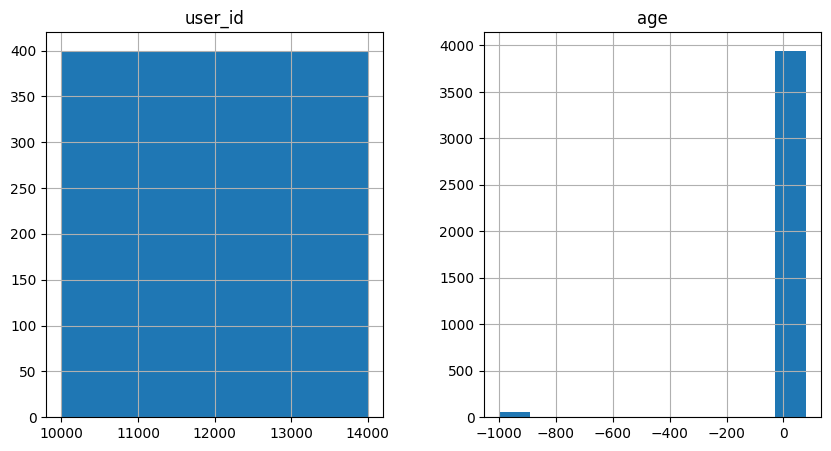

In [ ]:
num_users = users.select_dtypes(include='number')

num_users.describe()
num_users.hist(figsize=(10,5))
num_users.corr() # explorar columnas numéricas de users

**La columna `user_id`**
No aporta valor analítico. Es un identificador único, por eso su distribución es uniforme y la correlación con otras variables es prácticamente nula (~0.01). Se debe excluir de análisis estadísticos.

**La columna `age`**
Presenta un problema evidente de calidad de datos: hay valores negativos (incluso cercanos a -1000), lo cual no es lógico para una edad. Además, la distribución está altamente concentrada en valores cercanos a 0, lo que sugiere errores de captura o transformación. Esta columna requiere limpieza antes de cualquier análisis (por ejemplo, eliminar o corregir valores fuera de rango).

,id,user_id,duration,length
id,1.000000,-0.001371,0.000300,-0.000301
user_id,-0.001371,1.000000,0.002186,0.009388
duration,0.000300,0.002186,1.000000,-0.999694
length,-0.000301,0.009388,-0.999694,1.000000


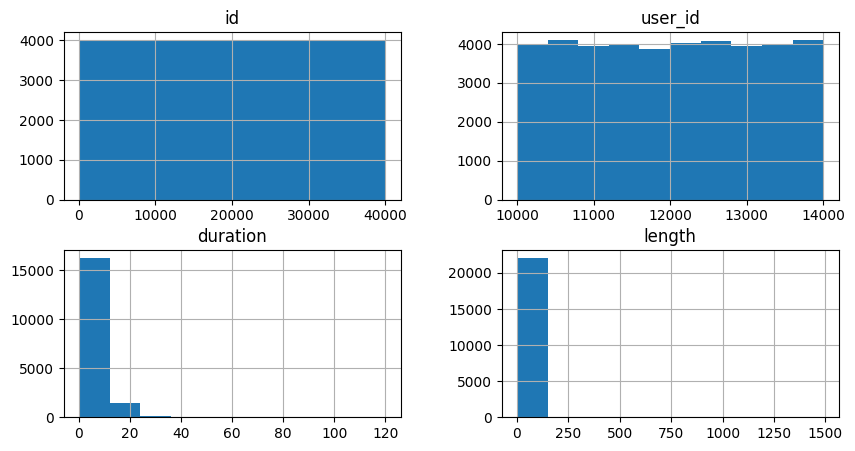

In [ ]:
num_usage = usage.select_dtypes(include='number')

num_usage.describe()
num_usage.hist(figsize=(10,5))
num_usage.corr() # explorar columnas numéricas de usage

**La columna `id`**
Es un identificador del registro. No debería de interpretarse como variable analítica, aunque aparezca como numérica. Su distribución uniforme solo indica que los registros están enumerados.

**La columna `user_id`**
También es un identificador. Sirve para unir tablas o agrupar información por usuario, pero no para calcular correlaciones o interpretar patrones estadísticos.

**La columna `duration`**
Representa una métrica real de uso. La mayoría de los valores se concentran en rangos bajos, pero hay algunos valores mucho más altos, lo que sugiere una distribución sesgada a la derecha y posibles outliers. Conviene revisar máximos, percentiles y valores faltantes.

**La columna `length`**
También parece ser una métrica de uso, pero presenta una relación casi perfectamente negativa con `duration` (`-0.999694`). Esto es sospechoso: podría indicar que una de las dos columnas aplica a tipos distintos de eventos, que hay valores faltantes codificados de forma especial, o que existe una transformación incorrecta.

**Conclusión general**
`id` y `user_id` deben excluirse del análisis estadístico. Las variables importantes son `duration` y `length`, pero antes de analizarlas conviene revisar su significado según la columna `type`, sus nulos y sus valores extremos.


In [ ]:

# columnas categóricas de users
columnas_user = ['city', 'plan']

# explorar valores inválidos o sentinels
for col in columnas_user:
    print(f"\n--- Columna: {col} ---")

    print("Valores únicos:")
    print(users[col].unique())

    print("\nConteo incluyendo nulos:")
    print(users[col].value_counts(dropna=False))

    print("\nProporción incluyendo nulos:")
    print(users[col].value_counts(dropna=False, normalize=True))



--- Columna: city ---
Valores únicos:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Conteo incluyendo nulos:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Proporción incluyendo nulos:
Bogotá      0.20200
CDMX        0.18250
Medellín    0.15400
NaN         0.11725
GDL         0.11250
Cali        0.10600
MTY         0.10175
?           0.02400
Name: city, dtype: float64

--- Columna: plan ---
Valores únicos:
['Basico' 'Premium']

Conteo incluyendo nulos:
Basico     2595
Premium    1405
Name: plan, dtype: int64

Proporción incluyendo nulos:
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64



**Valores inválidos o sentinels**

En `users`, la columna `city` presenta valores faltantes: 469 registros, equivalentes al 11.72% del total. Esto representa un problema moderado de calidad de datos porque `city` es una variable importante para segmentar usuarios por ubicación.

La acción recomendada sería no eliminar esos registros de inmediato, ya que se perdería información útil de usuarios. En su lugar, se podría imputar `city` con una categoría como `"unknown"` o `"not_available"` si no existe una fuente confiable para recuperar la ciudad original.

En la columna `plan` no se observan valores faltantes según la revisión inicial, por lo que no requiere tratamiento adicional. Solo convendría validar que sus categorías sean consistentes y no existan variantes escritas de forma diferente.

In [ ]:

# explorar columna categórica de usage
usage['type'] # completa el código
print("Valores únicos:")
print(usage['type'].unique())

print("\nFrecuencia:")
print(usage['type'].value_counts())

print("\nProporción:")
print(usage['type'].value_counts(normalize=True))

print("\nNulos:")
print(usage['type'].isna().sum())

Valores únicos:
['call' 'text']

Frecuencia:
text    22092
call    17908
Name: type, dtype: int64

Proporción:
text    0.5523
call    0.4477
Name: type, dtype: float64

Nulos:
0


**La columna `type`** presenta dos categorías: `text` y `call`, sin valores faltantes. La distribución está relativamente balanceada, aunque con ligera predominancia de `text` (55.23%) sobre `call` (44.77%). No se observan valores inconsistentes (como mayúsculas, espacios o variantes), lo que indica buena calidad en esta variable. Desde el punto de vista analítico, es una columna confiable para segmentar el comportamiento de uso y puede ser clave para interpretar métricas como `duration` y `length`, ya que probablemente cada tipo de evento se relaciona con una de estas medidas.



Encontré valores problemáticos principalmente en estas columnas:

**`users.age`**
Presenta valores inválidos, especialmente edades negativas. Una edad no puede ser menor a 0, por lo que estos registros deben tratarse como errores de calidad de datos. Se podrían convertir esas edades inválidas a `NaN` y luego decidir si se imputan, se eliminan o se revisan contra una fuente original.

**`users.city`**
Tiene valores faltantes. No necesariamente son “inválidos”, pero sí afectan la segmentación geográfica. Acción recomendada: no eliminar los usuarios; reemplazar los nulos por una categoría como `"unknown"` o `"not_available"`.

**`users.churn_date`**
Tiene muchos valores faltantes, pero aquí no necesariamente son un error. Probablemente significan que el usuario sigue activo. Acción recomendada: conservar la columna y crear una variable derivada como `is_churned`, donde si `churn_date` está vacío sea usuario activo.

**`usage.duration` y `usage.length`**
Tienen muchos valores faltantes, pero podrían estar relacionados con el tipo de uso. Por ejemplo, `duration` puede aplicar a llamadas y `length` a mensajes. Acción recomendada: analizar estas columnas junto con `usage.type` antes de imputar o eliminar.

**`usage.type`**
No presenta valores inválidos ni sentinels visibles. Solo contiene `call` y `text`, sin nulos, por lo que no requiere limpieza adicional.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
sorted(users['reg_date'].dt.year.dropna().unique())

[2022, 2023, 2024, 2026]


En `reg_date`, se observan los años **2022, 2023, 2024 y 2026**.
El año **2026 es sospechoso**, ya que corresponde a una fecha futura respecto al contexto del dataset, lo que indica posibles errores de captura o registro.

Estos registros deberían **revisarse o tratarse como datos inválidos**. Una opción es convertirlos a valores nulos (`NaT`) para evitar que afecten el análisis, o filtrarlos si representan una proporción muy baja.


In [ ]:
# Revisar los años presentes en `date` de usage
sorted(usage['date'].dt.year.dropna().unique())

[2024.0]

En la columna `date` del dataset `usage`, se observa que todos los registros corresponden únicamente al año **2024**. Esto indica consistencia temporal en los datos y no se identifican fechas fuera de rango o sospechosas.

Como acción, no se requiere limpieza adicional en esta columna, ya que los datos son coherentes con el periodo de análisis.

**Fechas fuera de rango**

En el dataset `users`, la columna `reg_date` presenta un valor fuera de rango: el año **2026**, que corresponde a una fecha futura y no debería existir en el contexto del análisis. Esto sugiere un error de captura o registro.

Como acción, estos registros deberían **tratarse como inválidos**. Se recomienda convertirlos a valores nulos (`NaT`) o filtrarlos, dependiendo de su proporción, para evitar que distorsionen el análisis.

En el dataset `usage`, la columna `date` solo contiene el año **2024**, lo cual es consistente y no presenta anomalías.

Como acción, no se requiere limpieza adicional en esta columna.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age

users['age'] = pd.to_numeric(users['age'], errors='coerce')

age_mediana = users.loc[users['age'] != -999, 'age'].median()

users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:

# Reemplazar ? por NA en city

users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:

# Reemplazar ? por NA en city

users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage para duration
pd.crosstab(
    usage['type'],
    usage['duration'].isna(),
    normalize='index'
)

duration,False,True
type,,
call,1.000000,0.000000
text,0.000724,0.999276


In [ ]:
# Verificación MAR en usage para length
pd.crosstab(
    usage['type'],
    usage['length'].isna(),
    normalize='index'
)

length,False,True
type,,
call,0.00067,0.99933
text,1.00000,0.00000


**Diagnóstico:**

Los valores nulos en `duration` y `length` no son aleatorios; dependen completamente de la variable `type`. En llamadas (`call`), `duration` siempre está presente y `length` casi siempre es nulo. En mensajes (`text`), ocurre lo contrario: `length` siempre está presente y `duration` casi siempre es nulo.

Esto indica que los nulos son **estructurales (no errores)**: cada variable aplica solo a un tipo de evento. Por lo tanto, **no deben imputarse ni eliminarse**. La acción correcta es mantenerlos como nulos y analizarlos de forma segmentada por `type` (por ejemplo, analizar `duration` solo en `call` y `length` solo en `text`).


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Agrupar información por usuario
usage_agg = (
    usage
    .groupby("user_id")
    .agg({
        "is_text": "sum",
        "is_call": "sum",
        "duration": "sum"
    })
    .reset_index()
)

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile[
    ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
plan_pct = user_profile['plan'].value_counts(normalize=True) * 100
plan_pct.round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

In [ ]:
user_profile['age'].notna().sum()

4000

In [ ]:
users['age'] = pd.to_numeric(users['age'], errors='coerce')

# eliminar valores absurdos (ej: negativos o >100)
users.loc[(users['age'] < 0) | (users['age'] > 100), 'age'] = pd.NA

# imputar con mediana
users['age'] = users['age'].fillna(users['age'].median())

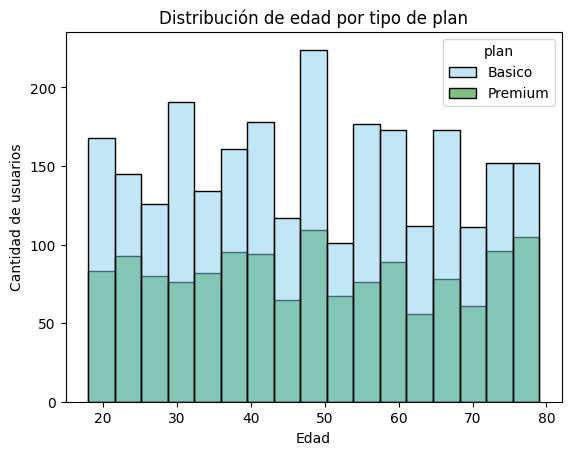

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
Distribución bastante uniforme
La edad está distribuida de forma relativamente homogénea entre ~18 y ~80 años. No hay un rango dominante claro la base de usuarios es diversa en edad.
No hay segmentación fuerte por plan
Básico y Premium se superponen casi completamente en todos los rangos de edad.
- La edad no parece ser un driver de elección de plan.
Ligera mayor presencia en Básico
En casi todos los rangos hay más usuarios en Básico que en Premium.
- Posible tema de precio o valor percibido.
Picos en edades medias (~40–55)
Se observa mayor densidad en edades medias.
- Este podría ser el segmento más activo o más representado.
No hay sesgo claro (distribución cercana a uniforme)
No está claramente sesgada a derecha o izquierda → no hay concentración en jóvenes o mayores.

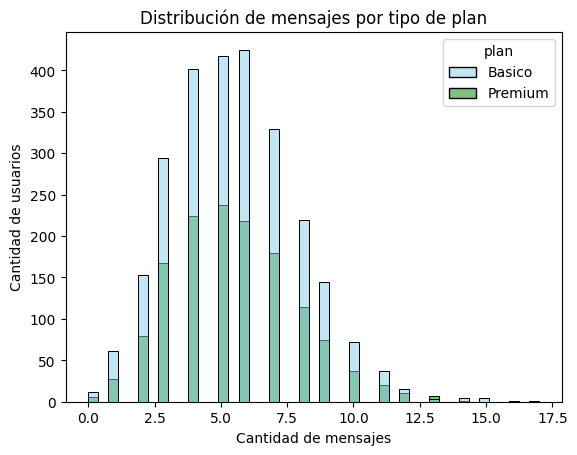

In [ ]:
# Histograma para visualizar cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
* La distribución está sesgada a la derecha. La mayoría de los usuarios envía entre 3 y 7 mensajes, mientras que pocos usuarios tienen un volumen alto de mensajes.

* El plan Básico tiene más usuarios en casi todos los rangos, lo que indica que es el plan con mayor adopción general.

* El plan Premium aparece con menor volumen total, pero mantiene presencia en rangos medios y altos de mensajes. Esto sugiere que algunos usuarios Premium tienen un uso más intensivo.

* Hay pocos usuarios con más de 10 mensajes, por lo que pueden considerarse usuarios de alto uso. Conviene analizarlos por separado para entender mejor su comportamiento.

* La cantidad de mensajes parece ser una variable más útil que la edad para diferenciar el comportamiento entre planes.


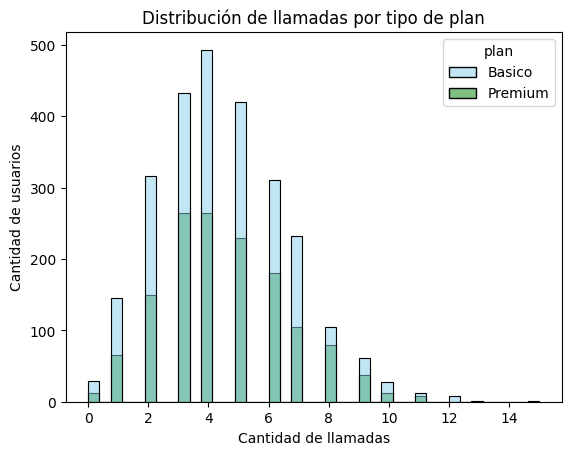

In [ ]:
# Histograma para visualizar cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
* La distribución también está sesgada a la derecha. La mayoría de los usuarios realiza entre 3 y 6 llamadas, mientras que pocos usuarios tienen un volumen alto.

* El plan Básico concentra la mayor cantidad de usuarios en todos los rangos, lo que confirma que es el plan predominante.

* El plan Premium tiene menor volumen total, pero se mantiene presente en los rangos medios y ligeramente altos, lo que sugiere un uso relativamente más intensivo en algunos usuarios.

* A partir de 7–8 llamadas, la cantidad de usuarios disminuye notablemente en ambos planes, lo que indica que los usuarios de alto uso son pocos.

* El patrón de llamadas es muy similar al de mensajes, aunque la separación entre planes es menos evidente, lo que sugiere que las llamadas diferencian menos el comportamiento entre Básico y Premium.


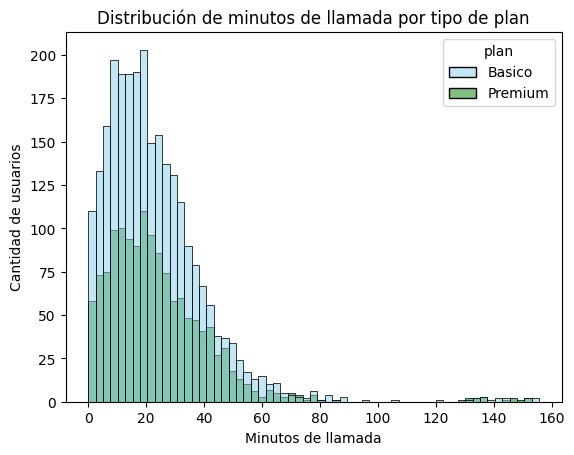

In [ ]:
# Histograma para visualizar cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de minutos de llamada por tipo de plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
Insi
* La distribución está fuertemente sesgada a la derecha. La mayoría de los usuarios consume pocos minutos (entre ~5 y 30), mientras que existe una cola larga de usuarios con consumo alto.

* El plan Básico concentra más usuarios en los rangos bajos y medios, lo que indica un uso más moderado en promedio.

* El plan Premium, aunque tiene menos usuarios, aparece con mayor presencia relativa en la cola alta (60+ minutos), lo que sugiere que los usuarios más intensivos tienden a estar en este plan.

* Existen outliers claros (usuarios con más de 100 minutos), que representan casos de uso intensivo y pueden influir en promedios.

* A diferencia de mensajes y llamadas, los minutos de llamada sí muestran una diferenciación más clara entre planes, lo que sugiere que el consumo de minutos es un mejor indicador para segmentar usuarios o justificar el plan Premium.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

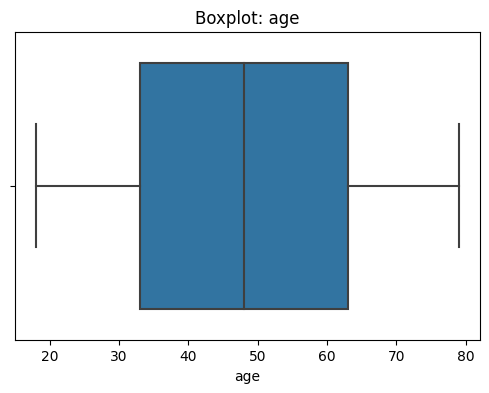

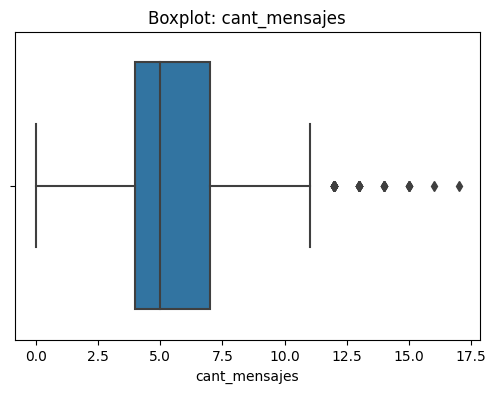

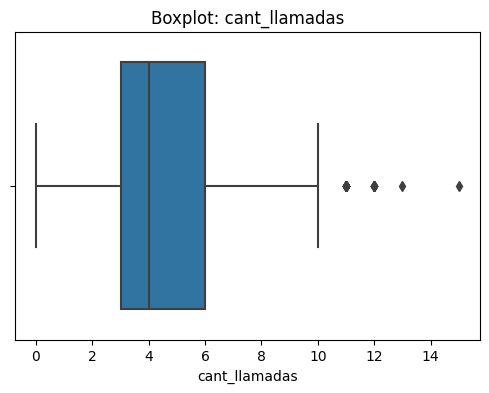

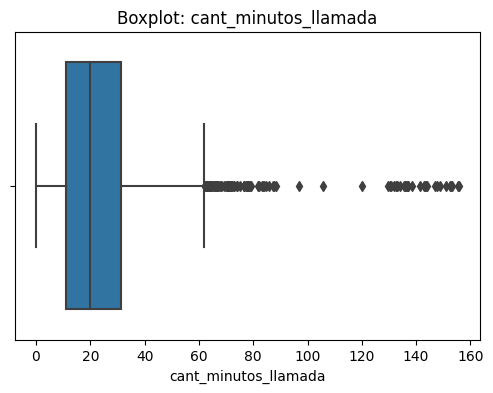

In [ ]:

# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:

* **Age:** no presenta outliers visibles. La edad se distribuye dentro de un rango razonable, aproximadamente entre 18 y 80 años, por lo que no parece requerir tratamiento adicional.

* **cant_mensajes:** presenta algunos outliers superiores. La mayoría de usuarios envía entre 4 y 7 mensajes, pero hay pocos usuarios con más de 11 mensajes. Estos valores parecen representar usuarios de alto uso, no necesariamente errores.

* **cant_llamadas:** también presenta outliers superiores. La mayoría de usuarios realiza entre 3 y 6 llamadas, mientras que pocos usuarios superan las 10 llamadas. Conviene mantenerlos si representan comportamiento real.

* **cant_minutos_llamada:** presenta muchos outliers superiores y una cola larga. La mayoría de usuarios acumula pocos minutos de llamada, pero algunos superan ampliamente los 60 minutos. Estos casos podrían representar usuarios intensivos, por lo que conviene analizarlos por separado antes de eliminarlos.


In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f"\nColumna: {col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"Límite superior: {limite_superior}")
    print(f"Máximo real: {user_profile[col].max()}")


Columna: cant_mensajes
Q1: 4.0
Q3: 7.0
Límite superior: 11.5
Máximo real: 17.0

Columna: cant_llamadas
Q1: 3.0
Q3: 6.0
Límite superior: 10.5
Máximo real: 15.0

Columna: cant_minutos_llamada
Q1: 11.12
Q3: 31.415
Límite superior: 61.8575
Máximo real: 155.69


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
* **cant_mensajes:** mantener los outliers. El límite superior es **11.5** y el máximo real es **17**, por lo que los valores extremos no están demasiado alejados. Parecen representar usuarios con mayor actividad de mensajería, no errores.

* **cant_llamadas:** mantener los outliers. El límite superior es **10.5** y el máximo real es **15**. Aunque hay usuarios por encima del rango esperado, la diferencia no es extrema y puede reflejar usuarios más activos.

* **cant_minutos_llamada:** mantener, pero analizar por separado. El límite superior es **61.86** y el máximo real es **155.69**, lo que indica outliers más fuertes. No los eliminaría automáticamente, porque pueden representar usuarios intensivos, pero conviene segmentarlos para entender si son casos reales o posibles anomalías.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso

condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

valores = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(
    condiciones,
    valores,
    default='Alto uso'
)

# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

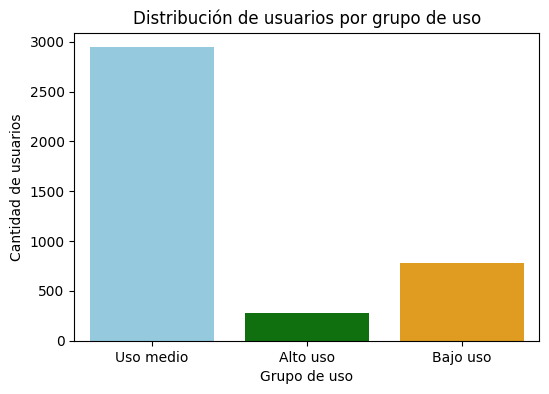

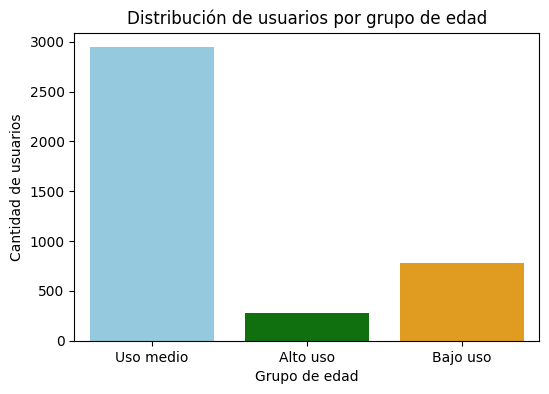

In [ ]:
# Visualización de los segmentos por uso
# Gráfico 1: grupo_uso
plt.figure(figsize=(6,4))
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    palette=['skyblue', 'green', 'orange']
)
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()


# Gráfico 2: grupo_edad
plt.figure(figsize=(6,4))
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    palette=['skyblue', 'green', 'orange']
)
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [ ]:
def clasificar_edad(edad):
    if edad < 30:
        return 'Joven'
    elif edad < 50:
        return 'Adulto'
    else:
        return 'Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

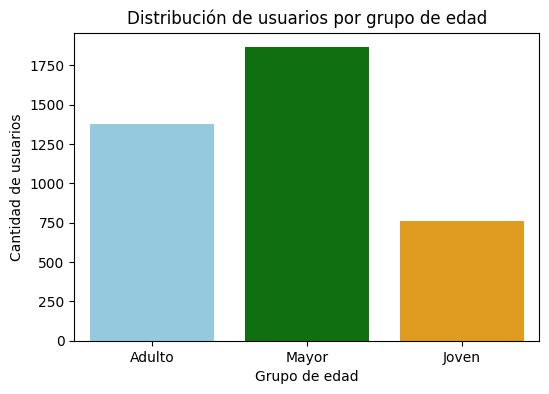

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=user_profile,
    x='grupo_edad',
    palette=['skyblue', 'green', 'orange']
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

* En `users`, la columna `city` tenía **469 valores nulos**, equivalentes al **11.72%**. Se recomienda conservar los registros y clasificar esos casos como ubicación desconocida.
* En `users`, `churn_date` tenía **3534 nulos** (**88.35%**), pero estos probablemente indican usuarios activos, no errores.
* En `usage`, `duration` y `length` tenían muchos nulos, pero se confirmó que dependen de `type`: `duration` aplica a llamadas y `length` a mensajes.
* También se detectaron valores inválidos en `age`, como `-999`, que fueron corregidos usando la mediana.

🔍 **Segmentos por Edad**

* La edad se distribuye de forma amplia y relativamente uniforme entre los usuarios.
* No se observa una diferencia clara entre usuarios Básico y Premium según edad.
* Esto indica que la edad por sí sola no parece explicar la elección del plan.

📊 **Segmentos por Nivel de Uso**

* Se identificaron usuarios de **bajo uso**, **uso medio** y **alto uso** según cantidad de llamadas y mensajes.
* El plan Básico concentra más usuarios, pero Premium tiene mayor presencia relativa entre usuarios con consumo más intensivo.
* Los minutos de llamada muestran una diferencia más clara entre planes que la edad o la cantidad de mensajes.

➡️ Esto sugiere que el **nivel de uso** es una variable más útil que la edad para segmentar clientes y detectar oportunidades comerciales. Los usuarios de uso medio y alto, especialmente quienes acumulan más minutos de llamada, parecen tener mayor valor potencial para ConnectaTel.

💡 **Recomendaciones**

* Mantener planes simples y accesibles para usuarios de bajo uso.
* Diseñar campañas de upgrade hacia Premium para usuarios de uso medio.
* Crear beneficios o paquetes adicionales para usuarios de alto consumo, especialmente en minutos de llamada.
* Analizar por separado a los outliers de alto consumo, ya que podrían representar clientes valiosos para retención, upsell o planes especializados.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`